<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()

X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=42, stratify=iris.target
)

# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)

train_accuracy, test_accuracy

(1.0, 0.9333333333333333)

# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

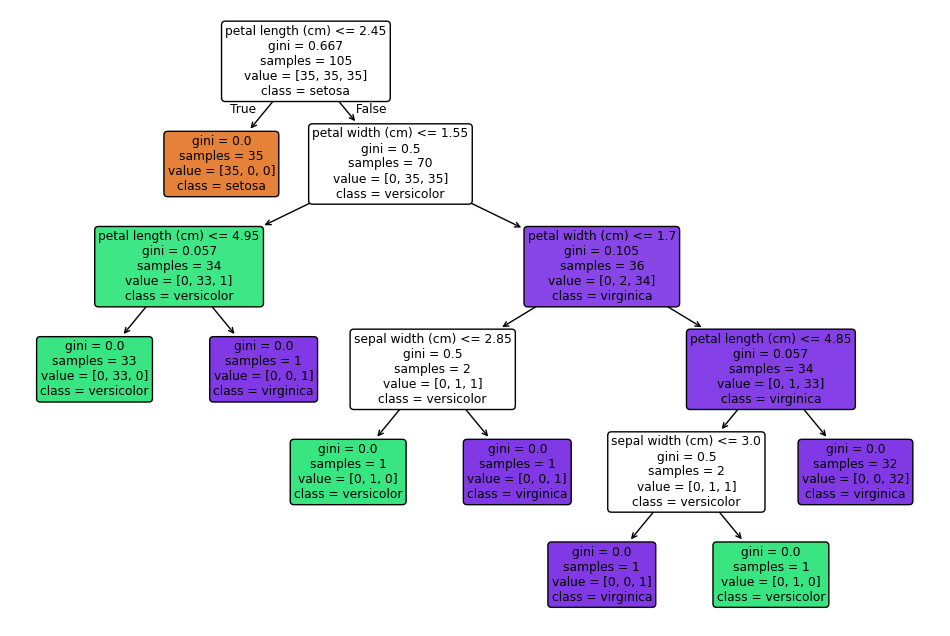

1. Atributo na raiz: petal length (cm)
2. Profundidade da árvore: 5


In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
)
plt.show()

root_attribute = iris.feature_names[clf.tree_.feature[0]]
tree_depth = clf.get_depth()

print(f"1. Atributo na raiz: {root_attribute}")
print(f"2. Profundidade da árvore: {tree_depth}")

**Adicione seu texto de solução aqui**.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

results = []

for max_depth in range(1, 10):
    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    clf.fit(X_train, y_train)

    train_accuracy = clf.score(X_train, y_train)
    test_accuracy = clf.score(X_test, y_test)
    tree_depth = clf.get_depth()
    num_leaves = clf.get_n_leaves()

    results.append({
        "max_depth": max_depth,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "tree_depth": tree_depth,
        "num_leaves": num_leaves
    })

clf = DecisionTreeClassifier(max_depth=None, random_state=42)
clf.fit(X_train, y_train)

train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)
tree_depth = clf.get_depth()
num_leaves = clf.get_n_leaves()

results.append({
    "max_depth": None,
    "train_accuracy": train_accuracy,
    "test_accuracy": test_accuracy,
    "tree_depth": tree_depth,
    "num_leaves": num_leaves
})

results_df = pd.DataFrame(results)

results_df

,max_depth,train_accuracy,test_accuracy,tree_depth,num_leaves
0,1.0,0.666667,0.666667,1,2
1,2.0,0.971429,0.888889,2,3
2,3.0,0.980952,0.977778,3,5
3,4.0,0.990476,0.888889,4,7
4,5.0,1.000000,0.933333,5,8
5,6.0,1.000000,0.933333,5,8
6,7.0,1.000000,0.933333,5,8
7,8.0,1.000000,0.933333,5,8
8,9.0,1.000000,0.933333,5,8
9,NaN,1.000000,0.933333,5,8


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini.fit(X_train, y_train)

train_accuracy_gini = clf_gini.score(X_train, y_train)
test_accuracy_gini = clf_gini.score(X_test, y_test)

tree_depth_gini = clf_gini.get_depth()

clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy.fit(X_train, y_train)

train_accuracy_entropy = clf_entropy.score(X_train, y_train)
test_accuracy_entropy = clf_entropy.score(X_test, y_test)

tree_depth_entropy = clf_entropy.get_depth()

comparison = {
    "Criterion": ["Gini", "Entropy"],
    "Train Accuracy": [train_accuracy_gini, train_accuracy_entropy],
    "Test Accuracy": [test_accuracy_gini, test_accuracy_entropy],
    "Tree Depth": [tree_depth_gini, tree_depth_entropy],
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Criterion,Train Accuracy,Test Accuracy,Tree Depth
0,Gini,1.0,0.933333,5
1,Entropy,1.0,0.888889,6


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

   min_samples_split  train_accuracy  test_accuracy  tree_depth  num_leaves
0                  2        1.000000       0.933333           5           8
1                  5        0.980952       0.933333           4           6
2                 10        0.980952       0.933333           4           6
3                 20        0.980952       0.933333           4           6
4                 50        0.971429       0.888889           2           3


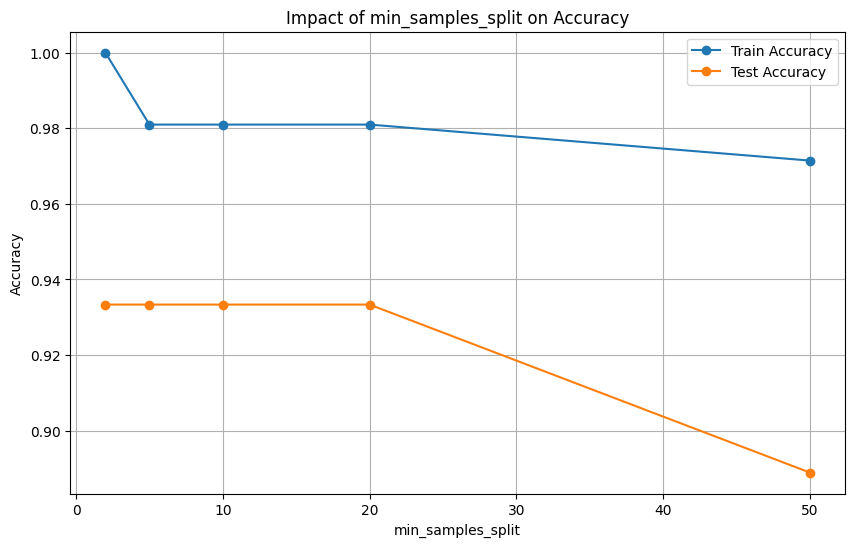

Best Model:
min_samples_split    2.000000
train_accuracy       1.000000
test_accuracy        0.933333
tree_depth           5.000000
num_leaves           8.000000
Name: 0, dtype: float64


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np

hyperparameter = "min_samples_split"
values = [2, 5, 10, 20, 50]

hyperparameter_results = []

for value in values:
    clf = DecisionTreeClassifier(random_state=42, **{hyperparameter: value})
    clf.fit(X_train, y_train)

    train_accuracy = clf.score(X_train, y_train)
    test_accuracy = clf.score(X_test, y_test)
    tree_depth = clf.get_depth()
    num_leaves = clf.get_n_leaves()

    hyperparameter_results.append({
        hyperparameter: value,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "tree_depth": tree_depth,
        "num_leaves": num_leaves
    })

hyperparameter_results_df = pd.DataFrame(hyperparameter_results)

print(hyperparameter_results_df)

plt.figure(figsize=(10, 6))
plt.plot(values, hyperparameter_results_df["train_accuracy"], label="Train Accuracy", marker='o')
plt.plot(values, hyperparameter_results_df["test_accuracy"], label="Test Accuracy", marker='o')
plt.xlabel(hyperparameter)
plt.ylabel("Accuracy")
plt.title(f"Impact of {hyperparameter} on Accuracy")
plt.legend()
plt.grid(True)
plt.show()

best_model = hyperparameter_results_df.loc[hyperparameter_results_df["test_accuracy"].idxmax()]
print("Best Model:")
print(best_model)